📊 Network Summary:
Network Summary  Value
Number of Nodes     34
Number of Edges     78

📊 Community Sizes:
              Louvain Community Size  Girvan-Newman Community Size
Community ID                                                      
0                                  6                          15.0
1                                  4                          19.0
2                                 10                           NaN
3                                 14                           NaN


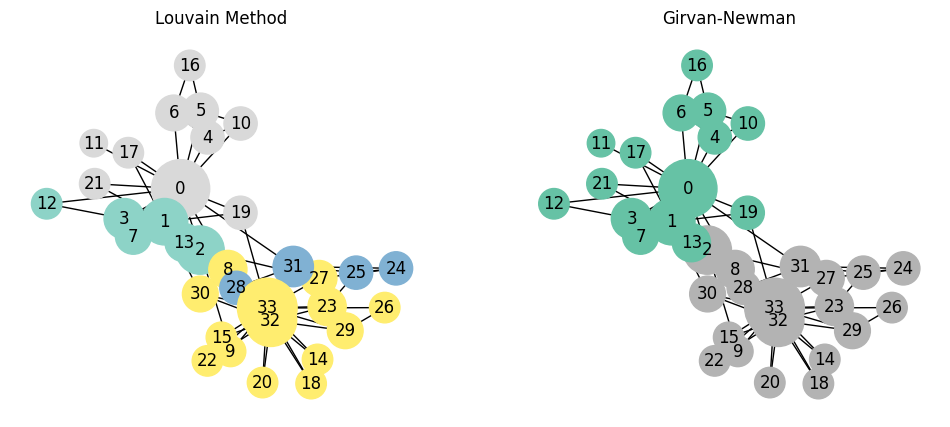

,node,degree,closeness,betweenness,eigenvector,louvain_comm,girvan_comm
0,0,0.484848,0.568966,0.437635,0.355483,2,0
1,1,0.272727,0.485294,0.053937,0.265954,0,0
2,2,0.303030,0.559322,0.143657,0.317189,0,1
3,3,0.181818,0.464789,0.011909,0.211174,0,0
4,4,0.090909,0.379310,0.000631,0.075966,2,0


In [1]:
!pip install -q python-louvain

import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain
import pandas as pd
from networkx.algorithms.community import girvan_newman

G = nx.karate_club_graph()

# 중심성
deg = nx.degree_centrality(G)
cls = nx.closeness_centrality(G)
btw = nx.betweenness_centrality(G)
eig = nx.eigenvector_centrality(G)

# Louvain
lvn = community_louvain.best_partition(G)

# Girvan-Newman (2개 커뮤니티까지)
gn_gen = girvan_newman(G)
gn_groups = tuple(sorted(c) for c in next(gn_gen))
gn = {}
for i, group in enumerate(gn_groups):
    for node in group:
        gn[node] = i

# 네트워크 크기
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# 커뮤니티 크기
louvain_sizes = pd.Series(list(lvn.values())).value_counts().sort_index()
louvain_sizes.name = "Louvain Community Size"

girvan_sizes = pd.Series(list(gn.values())).value_counts().sort_index()
girvan_sizes.name = "Girvan-Newman Community Size"

# 출력용 정리
network_summary = pd.DataFrame({
    "Network Summary": ["Number of Nodes", "Number of Edges"],
    "Value": [num_nodes, num_edges]
})

community_summary = pd.concat([louvain_sizes, girvan_sizes], axis=1)
community_summary.index.name = "Community ID"

# 결과 보기
print("📊 Network Summary:")
print(network_summary.to_string(index=False))

print("\n📊 Community Sizes:")
print(community_summary)
# 시각화
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
nx.draw(G, pos, with_labels=True, node_color=[lvn[n] for n in G.nodes()],
        node_size=[300 + 3000*deg[n] for n in G.nodes()], cmap=plt.cm.Set3)
plt.title("Louvain Method")

plt.subplot(1, 2, 2)
nx.draw(G, pos, with_labels=True, node_color=[gn[n] for n in G.nodes()],
        node_size=[300 + 3000*deg[n] for n in G.nodes()], cmap=plt.cm.Set2)
plt.title("Girvan-Newman")
plt.show()

# 데이터 정리
df = pd.DataFrame({
    'node': G.nodes(),
    'degree': [deg[n] for n in G.nodes()],
    'closeness': [cls[n] for n in G.nodes()],
    'betweenness': [btw[n] for n in G.nodes()],
    'eigenvector': [eig[n] for n in G.nodes()],
    'louvain_comm': [lvn[n] for n in G.nodes()],
    'girvan_comm': [gn[n] for n in G.nodes()]
})

df.head()